In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import joblib

load_dotenv('../.env')
engine = create_engine(os.getenv('DATABASE_URL'), pool_pre_ping=True, pool_recycle=300)

In [15]:
query = """
SELECT crime_type, district, community_area, hour, day_of_week, 
       month, is_weekend, year, latitude, longitude
FROM crime_incidents
WHERE district IS NOT NULL AND district != 0
ORDER BY RANDOM()
LIMIT 300000
"""
df = pd.read_sql(query, engine)
print(df.shape) 
df.head()

(300000, 10)


,crime_type,district,community_area,hour,day_of_week,month,is_weekend,year,latitude,longitude
0,CRIMINAL DAMAGE,6,71,8,0,3,False,2016,41.749517,-87.658567
1,ROBBERY,10,29,23,5,11,True,2013,41.865341,-87.695870
2,THEFT,9,58,10,0,2,False,2015,41.818585,-87.694525
3,CRIMINAL DAMAGE,25,20,0,5,8,True,2012,41.915885,-87.736297
4,THEFT,17,16,22,4,4,False,2012,41.953959,-87.701035


In [16]:
# Aggregate: count crimes per district per hour per day-of-week
agg = df.groupby(['district', 'hour', 'day_of_week', 'month', 'is_weekend']).size().reset_index(name='crime_count')

print(agg.shape)
print(agg['crime_count'].describe())

(43077, 6)
count    43077.000000
mean         6.964273
std          4.193703
min          1.000000
25%          4.000000
50%          6.000000
75%         10.000000
max         29.000000
Name: crime_count, dtype: float64


In [17]:
# Define "high risk" as top 25% of crime_count distribution
threshold = agg['crime_count'].quantile(0.75)
agg['high_risk'] = (agg['crime_count'] >= threshold).astype(int)

print(f"Threshold: {threshold}")
print(agg['high_risk'].value_counts())
print(f"\nHigh risk rate: {agg['high_risk'].mean():.2%}")

Threshold: 10.0
high_risk
0    32035
1    11042
Name: count, dtype: int64

High risk rate: 25.63%


In [18]:
features = ['district', 'hour', 'day_of_week', 'month', 'is_weekend']
X = agg[features]
y = agg['high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 34461, Test size: 8616


In [19]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


In [20]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"AUC-ROC:   {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\n", classification_report(y_test, y_pred))

AUC-ROC:   0.8811
Precision: 0.6744
Recall:    0.5681
F1 Score:  0.6167

               precision    recall  f1-score   support

           0       0.86      0.91      0.88      6407
           1       0.67      0.57      0.62      2209

    accuracy                           0.82      8616
   macro avg       0.77      0.74      0.75      8616
weighted avg       0.81      0.82      0.81      8616



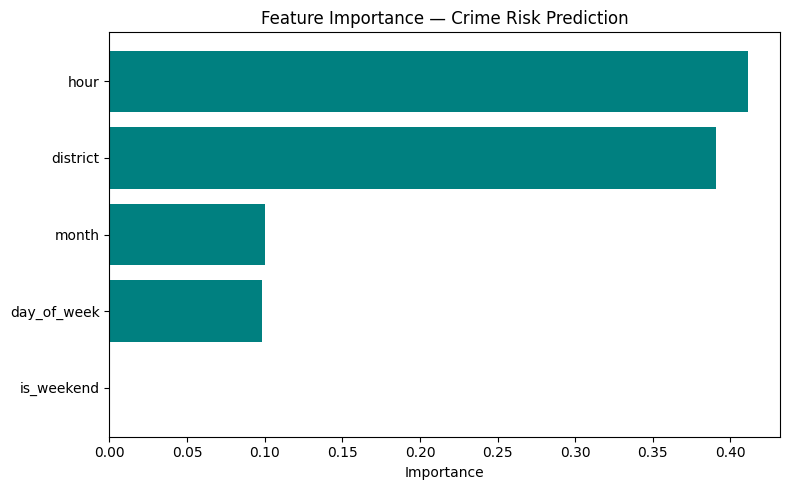

       feature  importance
1         hour    0.411332
0     district    0.390400
3        month    0.100129
2  day_of_week    0.098139
4   is_weekend    0.000000


In [21]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance — Crime Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)

In [22]:
joblib.dump(model, '../models/crime_risk_model.pkl')
print("Model saved to models/crime_risk_model.pkl")

Model saved to models/crime_risk_model.pkl


In [23]:
# Create all possible combinations
districts = df['district'].unique()
hours = list(range(24))
days = list(range(7))
months = list(range(1, 13))

from itertools import product

combos = list(product(districts, hours, days, months))
risk_df = pd.DataFrame(combos, columns=['district', 'hour', 'day_of_week', 'month'])
risk_df['is_weekend'] = risk_df['day_of_week'].isin([5, 6]).astype(int)

print(f"Total combinations: {len(risk_df):,}")

Total combinations: 48,384


In [24]:
risk_df['risk_score'] = model.predict_proba(
    risk_df[features]
)[:, 1]

# Scale to 0-100 for readability
risk_df['risk_score'] = (risk_df['risk_score'] * 100).round(1)

print(risk_df.sort_values('risk_score', ascending=False).head(10))

       district  hour  day_of_week  month  is_weekend  risk_score
10159        19     0            6      8           1   96.400002
13747        11    19            4      8           0   96.000000
13831        11    20            4      8           0   96.000000
14011        11    22            5      8           1   96.000000
13915        11    21            4      8           0   95.900002
13999        11    22            4      8           0   95.800003
10158        19     0            6      7           1   95.800003
13830        11    20            4      7           0   95.800003
13746        11    19            4      7           0   95.699997
14010        11    22            5      7           1   95.699997


In [25]:
# Save locally
risk_df.to_csv('../data/processed/district_risk_scores.csv', index=False)
print("Saved locally")

# Create table in Supabase and push
risk_df.to_sql(
    'district_risk_scores',
    engine,
    if_exists='replace',
    index=False
)
print(f"Pushed {len(risk_df):,} risk score rows to Supabase")

Saved locally
Pushed 48,384 risk score rows to Supabase


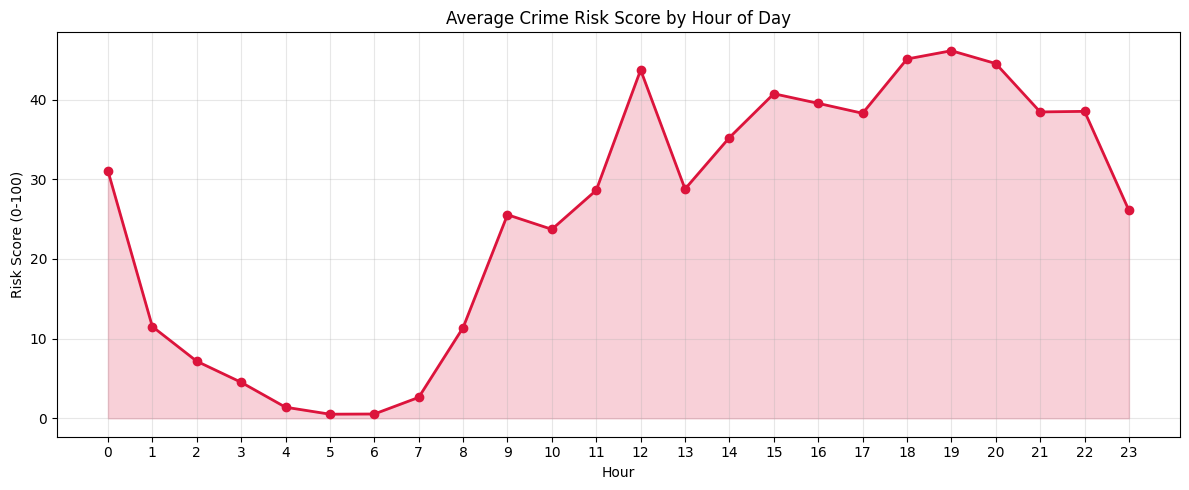

In [26]:
hourly_risk = risk_df.groupby('hour')['risk_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_risk['hour'], hourly_risk['risk_score'], 
         marker='o', color='crimson', linewidth=2)
plt.fill_between(hourly_risk['hour'], hourly_risk['risk_score'], alpha=0.2, color='crimson')
plt.title('Average Crime Risk Score by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Risk Score (0-100)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()